## Umbralizacion binaria y binaria inversa

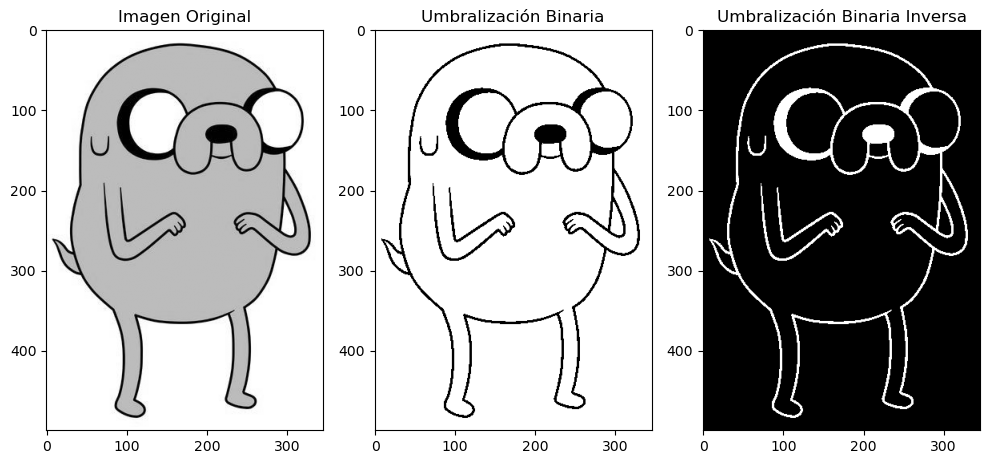

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

imagen=cv2.imread('jake.jpg',0)#lee en escala de grises

#umbralizacion binaria
_,umbral_binaria=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY)#se puede bajar los numeros y cambia la imagen 

#umbralizacion binaria inversa
_,umbral_binaria_inversa=cv2.threshold(imagen,127,255,cv2.THRESH_BINARY_INV)

plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.title('Imagen Original')
plt.imshow(imagen,cmap='gray')
plt.subplot(1,3,2)
plt.title('Umbralización Binaria')
plt.imshow(umbral_binaria,cmap='gray')
plt.subplot(1,3,3)
plt.title('Umbralización Binaria Inversa')
plt.imshow(umbral_binaria_inversa,cmap='gray')
plt.tight_layout()
plt.show()

## Transformacion de YUV2RGB a RGBYUV y viceversa

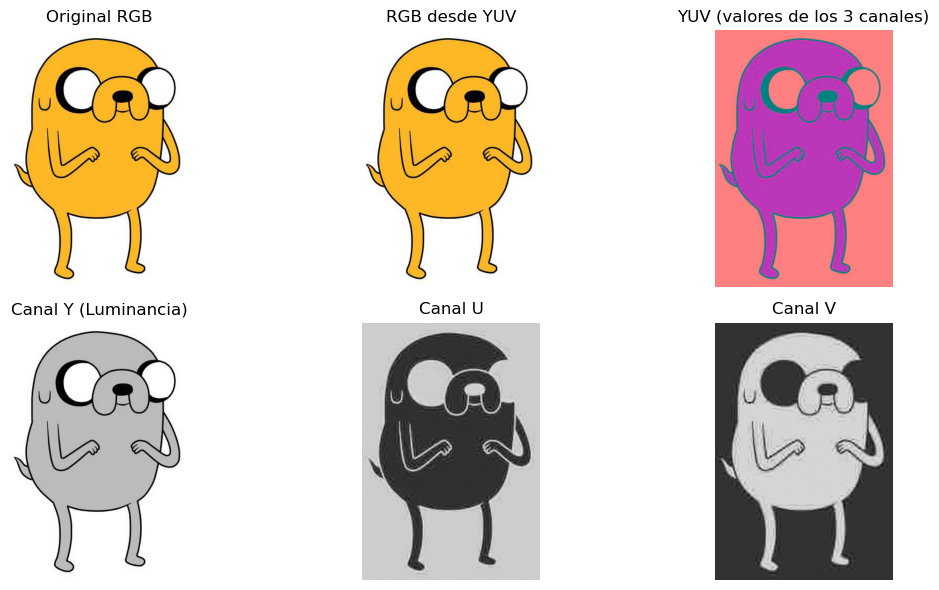

In [ ]:

import cv2
import matplotlib.pyplot as plt

imagen_bgr = cv2.imread('jake.jpg')
if imagen_bgr is None:
    raise FileNotFoundError('jake.jpg no encontrada en el directorio actual.')

imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

yuv = cv2.cvtColor(imagen_rgb, cv2.COLOR_RGB2YUV)

rgb_from_yuv = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

Y, U, V = cv2.split(yuv)

plt.figure(figsize=(12,6))
plt.subplot(2,3,1); plt.imshow(imagen_rgb); plt.title('Original RGB'); plt.axis('off')
plt.subplot(2,3,2); plt.imshow(rgb_from_yuv); plt.title('RGB desde YUV'); plt.axis('off')
plt.subplot(2,3,3); plt.imshow(yuv); plt.title('YUV (valores de los 3 canales)'); plt.axis('off')
plt.subplot(2,3,4); plt.imshow(Y, cmap='gray'); plt.title('Canal Y (Luminancia)'); plt.axis('off')
plt.subplot(2,3,5); plt.imshow(U, cmap='gray'); plt.title('Canal U'); plt.axis('off')
plt.subplot(2,3,6); plt.imshow(V, cmap='gray'); plt.title('Canal V'); plt.axis('off')
plt.tight_layout()
plt.show()

## Ejemplos de filtro Bayer 

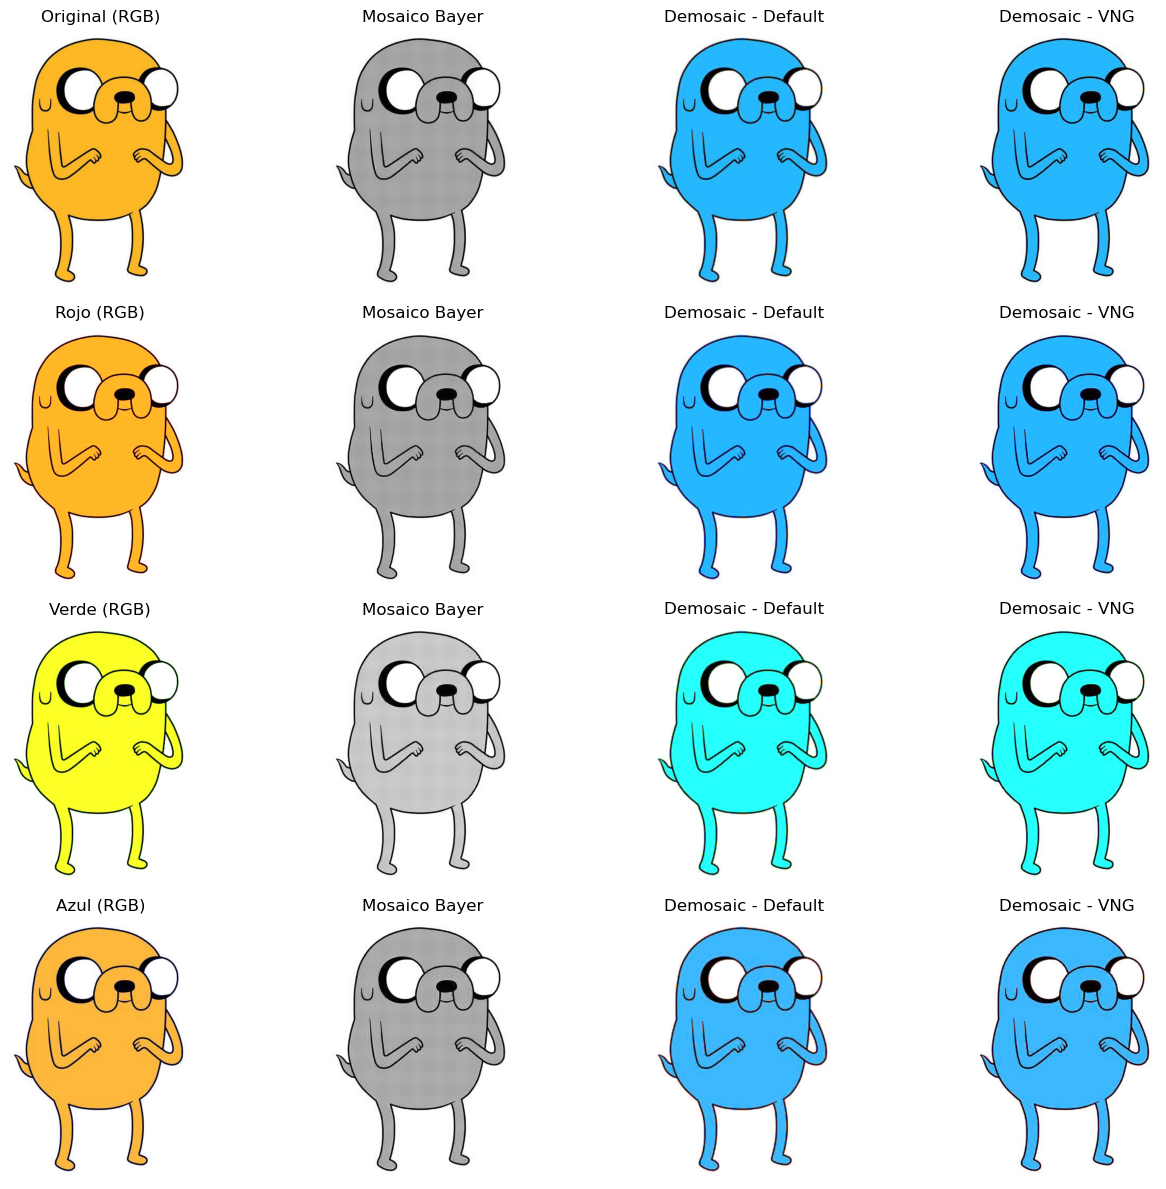

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv2.imread('jake.jpg')
if img_bgr is None:
    raise FileNotFoundError('jake.jpg no encontrada en el directorio actual.')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

def rgb_to_bayer(rgb):
    h,w,_ = rgb.shape
    bayer = np.zeros((h,w), dtype=rgb.dtype)
    bayer[0::2,0::2] = rgb[0::2,0::2,2]  # B
    bayer[0::2,1::2] = rgb[0::2,1::2,1]  # G
    bayer[1::2,0::2] = rgb[1::2,0::2,1]  # G
    bayer[1::2,1::2] = rgb[1::2,1::2,0]  # R
    return bayer

def boost_channel(rgb, channel, factor):
    out = rgb.astype(np.float32).copy()
    out[..., channel] = np.clip(out[..., channel] * factor, 0, 255)
    return out.astype(np.uint8)

orig = img_rgb
red = boost_channel(img_rgb, 0, 1.6)
green = boost_channel(img_rgb, 1, 1.6)
blue = boost_channel(img_rgb, 2, 1.6)

variants = [('Original', orig), ('Rojo', red), ('Verde', green), ('Azul', blue)]

results = []
for name, var in variants:
    bayer = rgb_to_bayer(var)
    dem_default = cv2.cvtColor(bayer, cv2.COLOR_BAYER_BG2BGR)
    dem_vng = cv2.cvtColor(bayer, cv2.COLOR_BAYER_BG2BGR_VNG)
    dem_default = cv2.cvtColor(dem_default, cv2.COLOR_BGR2RGB)
    dem_vng = cv2.cvtColor(dem_vng, cv2.COLOR_BGR2RGB)
    results.append((name, var, bayer, dem_default, dem_vng))

rows = len(results)
fig, axes = plt.subplots(rows, 4, figsize=(14, 3*rows))
for i, (name, var, bayer, dem_def, dem_vng) in enumerate(results):
    axes[i,0].imshow(var); axes[i,0].set_title(f'{name} (RGB)'); axes[i,0].axis('off')
    axes[i,1].imshow(bayer, cmap='gray'); axes[i,1].set_title('Mosaico Bayer'); axes[i,1].axis('off')
    axes[i,2].imshow(dem_def); axes[i,2].set_title('Demosaic - Default'); axes[i,2].axis('off')
    axes[i,3].imshow(dem_vng); axes[i,3].set_title('Demosaic - VNG'); axes[i,3].axis('off')

plt.tight_layout()
plt.show()